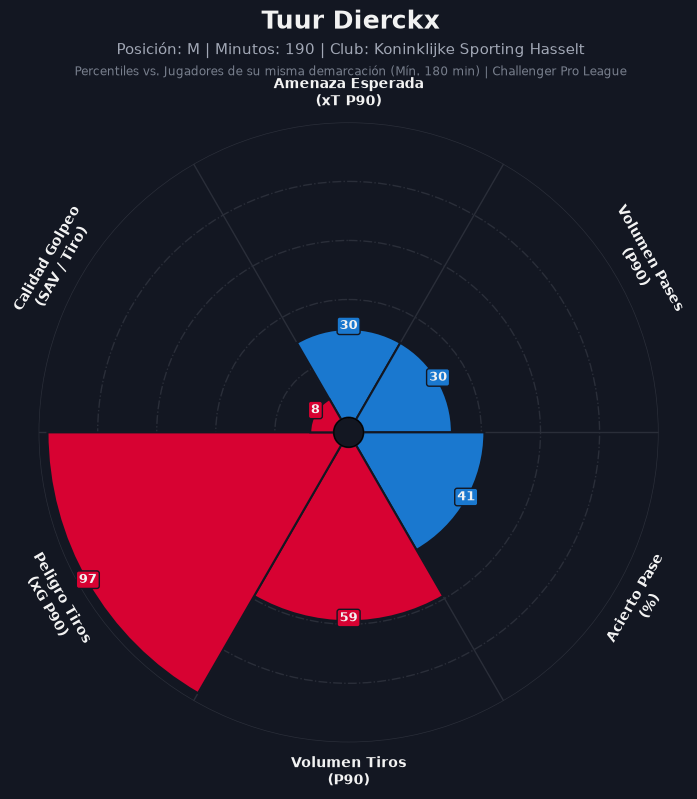

In [1]:
import duckdb
from mplsoccer import PyPizza
import matplotlib.pyplot as plt

con = duckdb.connect()

df_dierckx = con.execute("""
    SELECT 
        player_name,
        team_name,
        position,
        total_minutes,
        pct_xt,
        pct_passes_vol,
        pct_pass_acc,
        pct_shots,
        pct_xg,
        COALESCE(pct_sav_quality, 0) AS pct_sav_quality
    FROM '../data/gold/scouting_percentiles_gold.parquet'
    WHERE player_name = 'Tuur Dierckx'
""").df()

params = [
    "Amenaza Esperada\n(xT P90)",
    "Volumen Pases\n(P90)",
    "Acierto Pase\n(%)",
    "Volumen Tiros\n(P90)",
    "Peligro Tiros\n(xG P90)",
    "Calidad Golpeo\n(SAV / Tiro)"
]

values = [
    int(df_dierckx['pct_xt'].iloc[0]),
    int(df_dierckx['pct_passes_vol'].iloc[0]),
    int(df_dierckx['pct_pass_acc'].iloc[0]),
    int(df_dierckx['pct_shots'].iloc[0]),
    int(df_dierckx['pct_xg'].iloc[0]),
    int(df_dierckx['pct_sav_quality'].iloc[0])
]

# Definir colores por área del juego
# Azul para distribución/territorio (xT, pases), Rojo para ataque/remate (tiros, xG, SAV)
slice_colors = ["#1A78CF"] * 3 + ["#D70232"] * 3
text_colors = ["#F2F2F2"] * 6

# 1. Instanciar la pizza con fondo oscuro elegante
baker = PyPizza(
    params=params,
    background_color="#131722",     # Fondo oscuro estilo WyScout/StatsBomb
    straight_line_color="#2A2E39",   # Líneas divisorias sutiles
    straight_line_lw=1,
    last_circle_lw=1,
    last_circle_color="#2A2E39",
    other_circle_ls="-.",            # Líneas concéntricas punteadas (percentil 25, 50, 75)
    other_circle_lw=1,
    other_circle_color="#2A2E39"
)

# 2. Dibujar las rebanadas
fig, ax = baker.make_pizza(
    values,
    figsize=(8, 8.5),
    param_location=110,              # Distancia de las etiquetas de texto
    slice_colors=slice_colors,
    value_colors=text_colors,
    value_bck_colors=slice_colors,
    kwargs_slices=dict(edgecolor="#131722", zorder=2, linewidth=1.5),
    kwargs_params=dict(color="#F2F2F2", fontsize=10, va="center", weight="bold"),
    kwargs_values=dict(
        color="#F2F2F2", fontsize=9, zorder=3, weight="bold",
        bbox=dict(edgecolor="#131722", boxstyle="round,pad=0.2", lw=1)
    )
)

# 3. Título corporativo y subtítulos
fig.text(
    0.515, 0.97, f"{df_dierckx['player_name'].iloc[0]}", size=18,
    ha="center", color="#F2F2F2", weight="bold"
)
fig.text(
    0.515, 0.94,
    f"Posición: {df_dierckx['position'].iloc[0]} | Minutos: {int(df_dierckx['total_minutes'].iloc[0])} | Club: {df_dierckx['team_name'].iloc[0]}",
    size=11, ha="center", color="#A2A8B6"
)
fig.text(
    0.515, 0.915,
    "Percentiles vs. Jugadores de su misma demarcación (Mín. 180 min) | Challenger Pro League",
    size=8.5, ha="center", color="#787F8D"
)

plt.show()